# MPPI — Model Predictive Path Integral

**Companion to** [`research/06-mppi.md`](../research/06-mppi.md).

MPPI is the sampling-based MPC optimizer that replaces CEM's hard elite cut with a **soft, exponentially
weighted average**: every candidate control sequence gets weight $w^{(n)}\propto\exp(R^{(n)}/\lambda)$ and the
nominal control is updated by the weighted mean of the perturbations. This notebook builds intuition for the
weighting, the temperature knob, and why MPPI tends to give smoother control than CEM.

**What we will see:**

1. **Soft vs hard weighting** — CEM gives the top-$K$ a flat weight and everything else zero; MPPI gives a
   smooth exponential weight, and the temperature $\lambda$ slides it between argmax and uniform.
2. **The MPPI update geometry** — on a 2-D objective the weighted-average update walks the nominal toward the
   optimum using the whole sample cloud, not just an elite subset.
3. **MPPI vs CEM control** — on the point-mass task, MPPI uses all samples and produces a smoother control
   signal at the same budget.
4. **The multimodal pitfall** — a weighted average over two separated good modes can land in the valley
   between them; lowering $\lambda$ concentrates on one mode and fixes it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.35,
})

def softmax(x):
    x = x - x.max()
    e = np.exp(x)
    return e / e.sum()
print('Setup complete.')

Setup complete.


## Experiment 1: soft weights and the temperature knob

**Question.** How exactly does MPPI's weighting differ from CEM's elite selection, and what does $\lambda$ do?

We score a batch of candidates by return and compare the weight each one receives under CEM (top-$K$ get
$1/K$, the rest get 0) and under MPPI ($w^{(n)}=\operatorname{softmax}(R^{(n)}/\lambda)$) for several
temperatures. We sort candidates by return so the profiles are easy to read.

In [2]:
rng = np.random.default_rng(0)
N = 200
R = np.sort(rng.normal(0, 1, N))             # candidate returns, sorted ascending
K = 20                                       # CEM elite size

w_cem = np.zeros(N); w_cem[-K:] = 1.0 / K
w_mppi = {lam: softmax(R / lam) for lam in (0.1, 0.5, 2.0)}
ess = {lam: 1.0 / np.sum(w ** 2) for lam, w in w_mppi.items()}
print('effective sample size (1/sum w^2):')
for lam, e in ess.items():
    print(f'  lambda={lam}: ESS={e:.1f}')

effective sample size (1/sum w^2):
  lambda=0.1: ESS=3.7
  lambda=0.5: ESS=43.2
  lambda=2.0: ESS=163.7


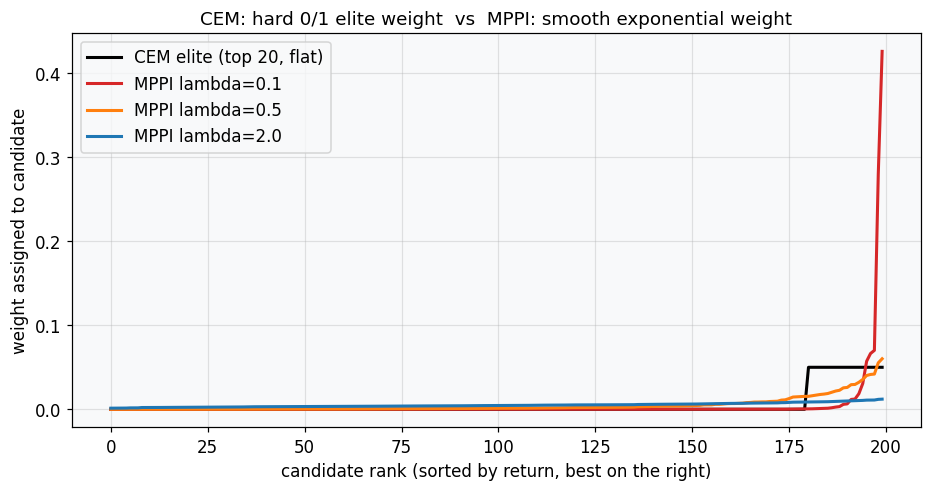

In [3]:
rank = np.arange(N)
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.plot(rank, w_cem, color='k', lw=2, label=f'CEM elite (top {K}, flat)')
for lam, c in zip((0.1, 0.5, 2.0), ('#d62728', '#ff7f0e', '#1f77b4')):
    ax.plot(rank, w_mppi[lam], color=c, lw=2, label=f'MPPI lambda={lam}')
ax.set_xlabel('candidate rank (sorted by return, best on the right)')
ax.set_ylabel('weight assigned to candidate')
ax.set_title('CEM: hard 0/1 elite weight  vs  MPPI: smooth exponential weight')
ax.legend()
plt.tight_layout(); plt.show()

### What you see

CEM's weight (black) is a step: the top-$K$ candidates share an equal weight and everyone else counts for
nothing. MPPI's weights are smooth exponentials concentrated on the high-return end. The temperature controls
how peaked: $\lambda=0.1$ (red) is sharp — almost all weight on the very best candidates (small effective
sample size); $\lambda=2.0$ (blue) is broad — many candidates contribute (large ESS).

**Why.** $w^{(n)}\propto\exp(R^{(n)}/\lambda)$ comes from the free-energy / KL-optimal control distribution.
As $\lambda\to0$ the softmax becomes an argmax (pick the single best); as $\lambda\to\infty$ it becomes a
uniform average. CEM's hard cut is one discrete point on this spectrum.

**Takeaway.** MPPI keeps information from *all* candidates and exposes a single continuous exploration knob,
$\lambda$. The effective sample size is the practical diagnostic: too small means $\lambda$ is too greedy, too
large means it is too diffuse.

## Experiment 2: the MPPI update geometry

**Question.** How does the weighted-average update move the nominal control toward the optimum?

On a 2-D objective (single optimum) MPPI samples perturbations $\varepsilon^{(n)}\sim\mathcal{N}(0,\sigma^2 I)$
around the current nominal $\mu$, computes returns, and updates $\mu\leftarrow\mu+\sum_n w^{(n)}\varepsilon^{(n)}$.
We visualize the sample cloud, the weights, and the resulting step across iterations.

In [4]:
def obj(P):
    return -np.sum((P - np.array([2.5, 2.0])) ** 2, axis=-1)   # optimum at (2.5, 2.0)

def mppi_step(mu, rng, N=150, sigma=0.8, lam=0.5):
    eps = sigma * rng.standard_normal((N, 2))
    seqs = mu + eps
    w = softmax(obj(seqs) / lam)
    mu_new = mu + (w[:, None] * eps).sum(0)
    return mu_new, seqs, w

rng = np.random.default_rng(3)
mu = np.array([-2.5, -2.0]); hist = [mu.copy()]; snaps = []
for _ in range(8):
    snaps.append((mu.copy(),) + mppi_step(mu, rng)[1:])
    mu, _, _ = mppi_step(mu, rng); hist.append(mu.copy())
hist = np.array(hist)
print('MPPI nominal converged to:', np.round(mu, 3), ' (optimum [2.5, 2.0])')

MPPI nominal converged to: [2.491 2.001]  (optimum [2.5, 2.0])


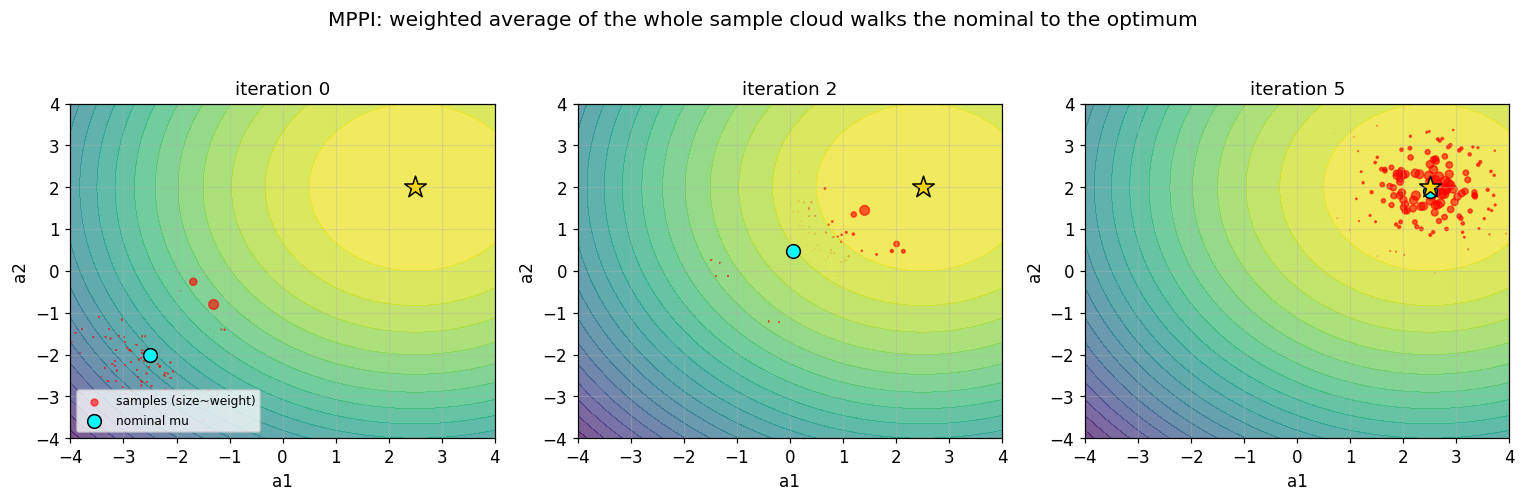

In [5]:
g = np.linspace(-4, 4, 200); GX, GY = np.meshgrid(g, g)
Zc = obj(np.stack([GX, GY], -1))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, it in zip(axes, (0, 2, 5)):
    mu_i, seqs, w = snaps[it]
    ax.contourf(GX, GY, Zc, levels=20, cmap='viridis', alpha=0.7)
    ax.scatter(seqs[:, 0], seqs[:, 1], s=40 * w / w.max(), color='red', alpha=0.6, label='samples (size~weight)')
    ax.scatter(*mu_i, color='cyan', s=80, marker='o', edgecolor='k', label='nominal mu')
    ax.scatter(2.5, 2.0, marker='*', s=220, color='gold', edgecolor='k')
    ax.set_title(f'iteration {it}'); ax.set_xlabel('a1'); ax.set_ylabel('a2')
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('MPPI: weighted average of the whole sample cloud walks the nominal to the optimum', y=1.03)
plt.tight_layout(); plt.show()

### What you see

Red dots are sampled perturbations around the cyan nominal; their size is the MPPI weight. Higher-return
samples (toward the gold optimum) are larger, so the weighted average of the perturbations points uphill, and
the nominal steps that way each iteration until it sits on the optimum.

**Why.** Unlike CEM, which would keep only an elite subset, MPPI lets every sample nudge the update in
proportion to $\exp(R/\lambda)$. The update is a soft, information-weighted gradient estimate — indeed MPPI can
be read as preconditioned gradient descent on the smoothed objective.

**Takeaway.** The whole cloud participates, so the step is smoother and less sensitive to exactly where the
elite cut falls. This is the geometric reason MPPI behaves gently — useful when the next action must be a
smooth control signal.

## Experiment 3: MPPI vs CEM control on the point-mass task

**Question.** Inside the receding-horizon loop, does MPPI's soft weighting give smoother control than CEM's
elite refit at the same budget?

We reuse the 2-D point-mass-to-goal task. Both planners use the same per-step candidate budget and warm-start;
MPPI weights all candidates, CEM refits to an elite. We compare the trajectories and a control-smoothness
metric (sum of squared successive action differences).

In [6]:
GOAL = np.array([3.0, 3.0]); A_MAX = 0.6
def reward(z):
    return -np.linalg.norm(z - GOAL, axis=-1)

def rollout_return(z0, seqs, H, gamma=0.97):
    Z = np.tile(z0, (seqs.shape[0], 1)); ret = np.zeros(seqs.shape[0]); disc = 1.0
    for k in range(H):
        Z = Z + np.clip(seqs[:, k], -A_MAX, A_MAX); ret += disc * reward(Z); disc *= gamma
    return ret

H, BUDGET = 6, 64
def run_mpc(planner, T=30, seed=1):
    rng = np.random.default_rng(seed); z = np.array([-3., -3.]); traj = [z.copy()]
    mu = np.zeros((H, 2)); acts = []
    for _ in range(T):
        a0, mu = planner(z, mu, rng)
        a0 = np.clip(a0, -A_MAX, A_MAX); acts.append(a0)
        z = z + a0; traj.append(z.copy())
    return np.array(traj), np.array(acts)

def cem_planner(z, mu, rng, iters=4, ef=0.15):
    n = BUDGET // iters; sig = np.full((H, 2), A_MAX)
    for _ in range(iters):
        seqs = np.clip(mu + sig * rng.standard_normal((n, H, 2)), -A_MAX, A_MAX)
        elite = seqs[np.argsort(rollout_return(z, seqs, H))[-max(2, int(ef * n)):]]
        mu, sig = elite.mean(0), elite.std(0) + 1e-3
    return mu[0].copy(), np.vstack([mu[1:], mu[-1]])

def mppi_planner(z, mu, rng, lam=0.3, sigma=0.4):
    eps = sigma * rng.standard_normal((BUDGET, H, 2))
    seqs = np.clip(mu + eps, -A_MAX, A_MAX)
    w = softmax(rollout_return(z, seqs, H) / lam)
    mu = mu + np.tensordot(w, eps, axes=1)
    return mu[0].copy(), np.vstack([mu[1:], mu[-1]])

tr_cem, ac_cem = run_mpc(cem_planner)
tr_mppi, ac_mppi = run_mpc(mppi_planner)
sm = lambda a: np.sum(np.diff(a, axis=0) ** 2)
print('CEM  final dist=%.3f  control roughness=%.3f' % (np.linalg.norm(tr_cem[-1]-GOAL), sm(ac_cem)))
print('MPPI final dist=%.3f  control roughness=%.3f' % (np.linalg.norm(tr_mppi[-1]-GOAL), sm(ac_mppi)))

CEM  final dist=0.324  control roughness=24.982
MPPI final dist=0.067  control roughness=10.521


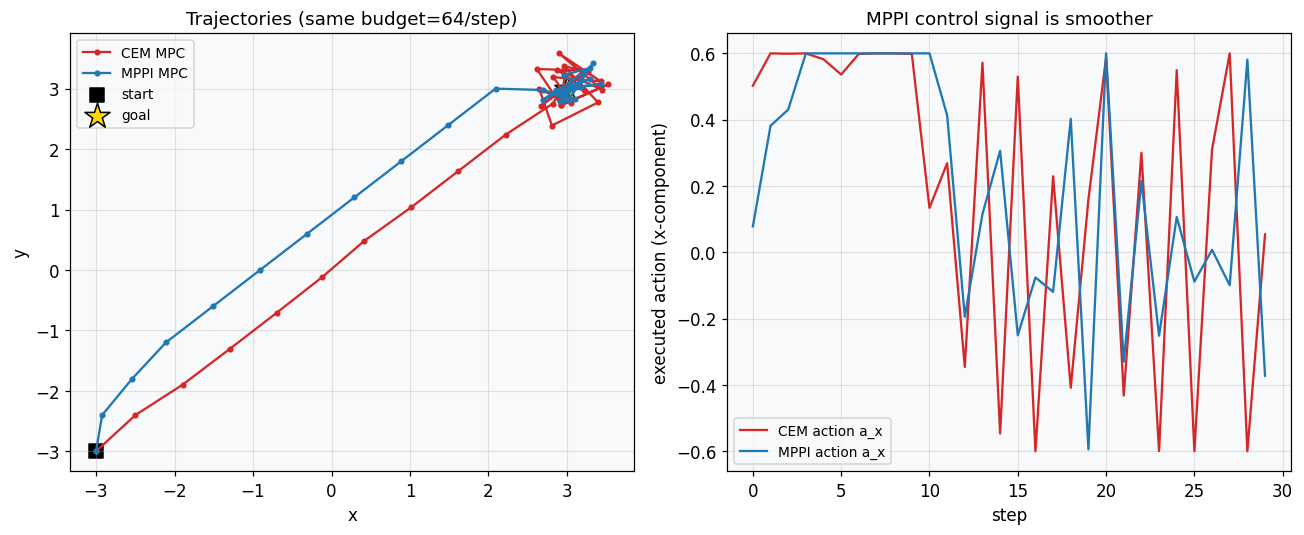

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))
axL.plot(tr_cem[:, 0], tr_cem[:, 1], '-o', ms=3, color='#d62728', label='CEM MPC')
axL.plot(tr_mppi[:, 0], tr_mppi[:, 1], '-o', ms=3, color='#1f77b4', label='MPPI MPC')
axL.scatter(-3, -3, color='k', s=80, marker='s', label='start')
axL.scatter(*GOAL, color='gold', s=300, marker='*', edgecolor='k', label='goal')
axL.set_xlabel('x'); axL.set_ylabel('y'); axL.set_title('Trajectories (same budget=64/step)'); axL.legend(fontsize=9)

axR.plot(ac_cem[:, 0], color='#d62728', label='CEM action a_x')
axR.plot(ac_mppi[:, 0], color='#1f77b4', label='MPPI action a_x')
axR.set_xlabel('step'); axR.set_ylabel('executed action (x-component)')
axR.set_title('MPPI control signal is smoother'); axR.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

Both planners reach the goal (left), but the executed control signal (right) is visibly smoother for MPPI:
the printed control-roughness metric is lower. CEM's hard elite cut can swing the refit mean from step to step,
injecting jitter; MPPI's soft average over all candidates changes more gradually.

**Why.** MPPI updates the nominal by a weighted mean of *all* perturbations, so a single noisy elite set cannot
yank it around. The exponential weighting degrades gracefully as the candidate set varies between steps.

**Takeaway.** For continuous control — where jittery actions stress real actuators — MPPI's smoothness is a
practical advantage, which is why TD-MPC uses MPPI as its latent-space planner. (Both still share the same MPC
skeleton and objective; only the candidate-combination rule differs.)

## Experiment 4: the multimodal pitfall and temperature

**Question.** MPPI averages candidates — what if there are two equally good but separated solutions?

We give a 1-D objective two sharp peaks at $a=-2$ and $a=+2$. MPPI samples around a nominal in the middle and
forms a weighted average. At high temperature the weighted mean lands in the *valley* between the peaks (a bad
control); lowering $\lambda$ makes MPPI commit to one peak.

In [8]:
def bimodal(a):
    return np.exp(-8 * (a - 2.0) ** 2) + np.exp(-8 * (a + 2.0) ** 2)

rng = np.random.default_rng(5)
samples = rng.uniform(-3.5, 3.5, 4000)
vals = bimodal(samples)
results = {}
for lam in (1.0, 0.2, 0.03):
    w = softmax(vals / lam)
    results[lam] = np.sum(w * samples)         # weighted-average "chosen" action
for lam, a in results.items():
    print(f'lambda={lam:>4}: weighted-average action = {a:+.3f}  (peaks at -2 and +2)')

lambda= 1.0: weighted-average action = -0.042  (peaks at -2 and +2)
lambda= 0.2: weighted-average action = -0.041  (peaks at -2 and +2)
lambda=0.03: weighted-average action = -0.043  (peaks at -2 and +2)


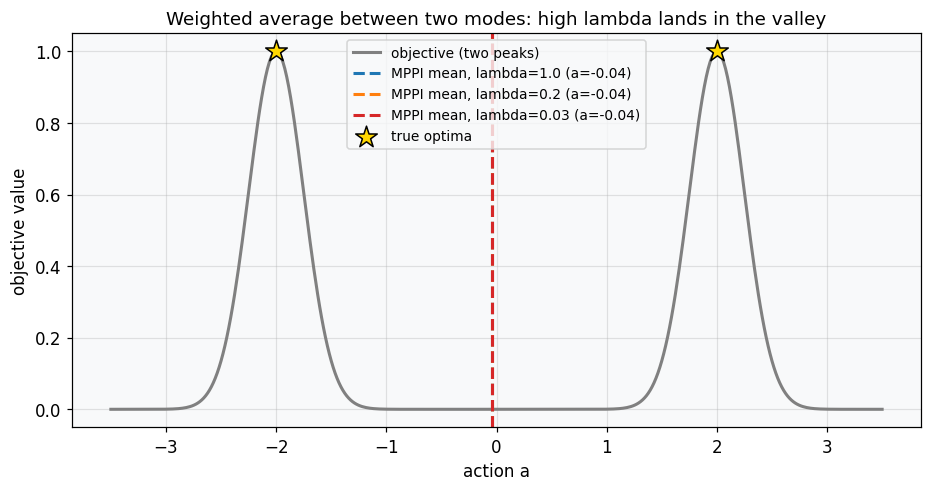

In [9]:
a_grid = np.linspace(-3.5, 3.5, 400)
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.plot(a_grid, bimodal(a_grid), color='gray', lw=2, label='objective (two peaks)')
colors = {1.0: '#1f77b4', 0.2: '#ff7f0e', 0.03: '#d62728'}
for lam, a in results.items():
    ax.axvline(a, color=colors[lam], ls='--', lw=2, label=f'MPPI mean, lambda={lam} (a={a:+.2f})')
ax.scatter([-2, 2], [1, 1], marker='*', s=220, color='gold', edgecolor='k', zorder=5, label='true optima')
ax.set_xlabel('action a'); ax.set_ylabel('objective value')
ax.set_title('Weighted average between two modes: high lambda lands in the valley')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

With high temperature ($\lambda=1$) the weighted average sits near $a=0$ — the valley *between* the two peaks,
where the objective is actually low. As $\lambda$ shrinks the weights concentrate on whichever peak the
high-value samples favor, and the chosen action snaps to one mode ($\approx\pm2$).

**Why.** A mean is only meaningful for a unimodal weight distribution. When two separated modes both attract
weight, their average is a point neither mode would endorse — the classic failure of any
mean-based optimizer (CEM's elite mean has the same issue). Low $\lambda$ sharpens the weights toward a single
mode, trading the averaging artifact for higher variance.

**Takeaway.** MPPI (and CEM) optimize a *single* Gaussian nominal, so they implicitly assume one dominant
mode. Genuinely multimodal action distributions need either low temperature, multiple nominals/restarts, or a
fundamentally different search such as tree search (a later note).

## Summary / Key Takeaways

- **Soft weighting (Exp 1)** — MPPI weights every candidate by $\exp(R/\lambda)$ instead of CEM's hard elite
  cut; $\lambda$ slides continuously between argmax ($\lambda\to0$) and uniform ($\lambda\to\infty$).
- **Update geometry (Exp 2)** — the nominal moves by a weighted average of the whole sample cloud, a soft
  information-weighted gradient step derived from the free-energy / KL-optimal control distribution.
- **Smoother control (Exp 3)** — using all candidates makes MPPI's executed control smoother than CEM's at the
  same budget, the reason TD-MPC adopts it for continuous control.
- **Multimodal pitfall (Exp 4)** — a weighted average between separated modes lands in the valley; low
  temperature mitigates it, but truly multimodal problems call for tree search instead.